# Boosting 

In [2]:
# import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, f1_score, recall_score
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [3]:
df = sns.load_dataset('iris')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.shape

(150, 5)

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

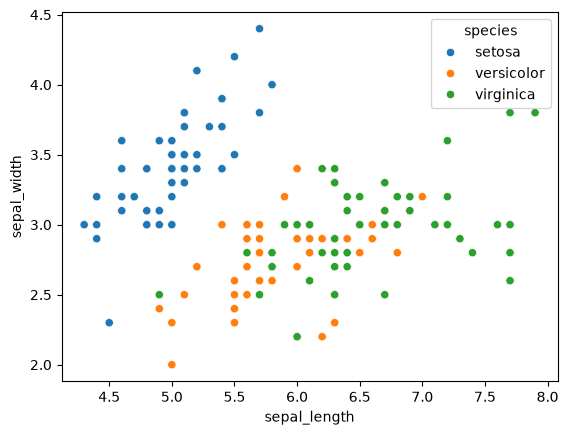

In [5]:
# plot the data
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)

In [21]:
# load the diamond dataset
df =  sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [22]:
# split the data into X and Y
X = df.drop('cut', axis=1)
y = df['cut']

# # encoded the input variable
le = LabelEncoder()
X['color']= le.fit_transform(X['color'])
X['clarity']= le.fit_transform(X['clarity'])
X['depth']= le.fit_transform(X['depth']) 
y = le.fit_transform(y)

# split the data into train and test
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
%%time

# train the decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

#predict the Decision tree
y_predict =  dt.predict(X_test)

# print the matrix
print('Accuracy-Score', accuracy_score(y_test, y_predict))
print('pecision score', precision_score(y_test, y_predict, average='micro'))
print('F1 score', f1_score(y_test, y_predict, average='micro'))
print('recall score', recall_score(y_test, y_predict, average='micro'))

Accuracy-Score 0.7047555257870061
pecision score 0.7047555257870061
F1 score 0.7047555257870061
recall score 0.7047555257870061
CPU times: total: 859 ms
Wall time: 912 ms


In [24]:
%%time

# train the random forest model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# predict the random forest 
y_pred = rf.predict(X_test)

# print the matrix
print('Accuracy-Score', accuracy_score(y_test, y_predict))
print('pecision score', precision_score(y_test, y_predict, average='micro'))
print('F1 score', f1_score(y_test, y_predict, average='micro'))
print('recall score', recall_score(y_test, y_predict, average='micro'))

Accuracy-Score 0.7047555257870061
pecision score 0.7047555257870061
F1 score 0.7047555257870061
recall score 0.7047555257870061
CPU times: total: 15.7 s
Wall time: 16.1 s


In [25]:
%%time
# train the xgboost model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# predict the boosting 
y_pred = xgb.predict(X_test)

# print the mtrix
print('Accuracy-Score', accuracy_score(y_test, y_pred))
print('pecision score', precision_score(y_test, y_pred, average='micro'))
print('F1 score', f1_score(y_test, y_pred, average='micro'))
print('recall score', recall_score(y_test, y_pred, average='micro'))

Accuracy-Score 0.7962491627595445
pecision score 0.7962491627595445
F1 score 0.7962491627595445
recall score 0.7962491627595445
CPU times: total: 16.4 s
Wall time: 3.8 s


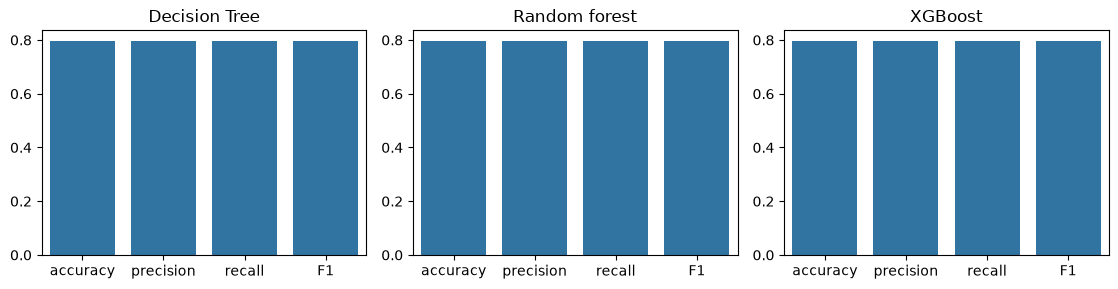

In [26]:
# make a bar plot that showing each of the matrix with respect to the model
plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
sns.barplot(x=['accuracy', 'precision', 'recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Decision Tree')
plt.subplot(1, 4, 2)
sns.barplot(x=['accuracy', 'precision', 'recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Random forest')
plt.subplot(1, 4, 3)
sns.barplot(x=['accuracy', 'precision', 'recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('XGBoost')
plt.tight_layout()
plt.show()



# Regression 

In [29]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Load dataset
df = sns.load_dataset("diamonds")

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

# One-Hot Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = XGBRegressor()
# Remove rows with missing values in features/target before fitting XGBoost
X = X.dropna()
y = y.loc[X.index]

# Re-split after cleaning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the regressor
model = XGBRegressor(random_state=42, objective="reg:squarederror")
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
# predict the boosting 
y_pred = model.predict(X_test)
y_pred

array([  785.949 ,  4642.5903, 16578.068 , ...,   832.4046,  4587.657 ,
        3780.203 ], dtype=float32)